In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, freqz, lfilter, filtfilt, iirnotch, butter, resample_poly, correlate
from sklearn.decomposition import PCA


%matplotlib widget


In [2]:
data = pd.read_csv('set-a-text/a21.csv',skiprows=[0,1],names=['time','channel1','channel2','channel3','channel4'],)
QRSpostions = np.loadtxt('set-a-text/a21.fqrs.txt',dtype=int,)

In [3]:
#check original data sampling rate
time_diffs = data["time"].diff().dropna()
estimated_fs = 1 / time_diffs.mean()

estimated_fs

np.float64(1000.0)

In [4]:
def changeSamplingRate(df: pd.DataFrame, original_fs: int = 1000, target_fs: int = 400,plot_result = False) -> pd.DataFrame:
    # Calculate the upsampling factor
    upsample_factor = target_fs / original_fs
    
    # Initialize a new dictionary to store resampled data
    resampled_data = {}

    # Adjust the time column
    original_time = df['time'].values
    total_duration = original_time[-1]  # Total time duration in seconds
    new_sample_count = int(len(original_time) * upsample_factor)
    resampled_data['time'] = np.linspace(0, total_duration, new_sample_count)

    for col in df.columns:
        if col != 'time':
                        # Resample the signal using polyphase resampling
            resampled_data[col] = resample_poly(df[col], up=target_fs, down=original_fs)


    if plot_result:
        channel_to_plot = df.columns[1] 

        plt.figure(figsize=(10, 4))
        plt.plot(df.time, df[channel_to_plot],label=f"Original {channel_to_plot} ({original_fs} Hz)",)
        plt.plot(resampled_data['time'], resampled_data[channel_to_plot], label=f"Target {channel_to_plot} ({target_fs} Hz)", alpha=0.5)
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.title(f"Change sampling rate {channel_to_plot}: {original_fs} Hz → {target_fs} Hz")
        plt.grid()
        plt.show()  

    return pd.DataFrame(resampled_data)

In [6]:
s1 = changeSamplingRate(data, original_fs=1000, target_fs=400)
sampling_rate = 400

In [544]:
s1.head()

,time,channel1,channel2,channel3,channel4
0,0.0000,-1.830712,-1.381587,1.983252,-3.711779
1,0.0025,-3.261788,-1.838935,3.253683,-5.921578
2,0.0050,-3.584599,-0.498169,3.179976,-6.022079
3,0.0075,-4.575428,-2.970805,3.348911,-6.207434
4,0.0100,-5.358417,-3.321220,3.168906,-4.944111


In [7]:
def clean_data(fecg_df:pd.DataFrame)->pd.DataFrame:
    """
    This function takes a dataframe of FECG and clean it by removing the NaN values and convert the values to numeric.
    """
    for i in fecg_df.columns:
        fecg_df[i] = pd.to_numeric(fecg_df[i], errors='coerce').fillna(0)
    return fecg_df

In [546]:
s1 = clean_data(s1)

In [8]:
def estimate_snr(signal, threshold_ratio=0.1):
    # Energy of signal
    signal_power = np.mean(signal ** 2)
    
    # Define "low energy" segments as noise
    threshold = threshold_ratio * np.max(np.abs(signal))
    noise = signal[np.abs(signal) < threshold]
    
    # If not enough noise samples, fallback
    if len(noise) < 10:
        return np.nan
    
    noise_power = np.mean(noise ** 2)
    snr = 10 * np.log10(signal_power / noise_power)
    return snr
def compute_channel_snrs(df):
    snrs = {}
    for col in df.columns:
        if col != 'time':
            snrs[col] = estimate_snr(df[col].values)
    return snrs

snrs = compute_channel_snrs(s1)
snrs

{'channel1': np.float64(10.27694972387884),
 'channel2': np.float64(9.970922103489636),
 'channel3': np.float64(11.716276002700571),
 'channel4': np.float64(10.523513669454905)}

In [9]:
def plot_filter_response(freq,freq_resp):
    """
    Plot the magnitude and phase response of the filter.
    """
    angles = np.unwrap(np.angle(freq_resp))  # Unwrapped phase
    # Magnitude response
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(freq, 20 * np.log10(abs(freq_resp)))
    plt.title('Magnitude Response of the High-Pass FIR Filter')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.xlim([0, 50])  # Match paper's x-axis
    plt.ylim([-40, 10])  # Match paper's y-axis
    plt.grid()

    # Phase response (unwrap to visualize better)
    plt.subplot(1, 2, 2)
    plt.plot(freq, angles, linewidth=1.5)
    plt.title('Phase Response of the High-Pass FIR Filter')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Phase (degree)')
    plt.grid()
    plt.xlim([0, 50])
    plt.ylim([-600, 0])  # Limit the y-axis for better visualization
    plt.show()

In [10]:
def wander_removal(signal, cutoff=3.0, fs=sampling_rate, num_taps=1001, 
                   plot_filter_coefs=False, plot_filter_resp=False, plot_result=False):
    """
    Apply a high-pass filter to remove baseline wander from the ECG signal.

    :param signal: ECG signal (numpy array)
    :param cutoff: Cut-off frequency (Hz)
    :param fs: Sampling frequency (Hz)
    :param num_taps: Number of taps (filter length, must be odd for FIR filter)
    :param plot_filter_coefs: Plot the filter coefficients
    :param plot_filter_resp: Plot the frequency response of the filter
    :param plot_result: Plot the original and filtered signals

    :return: Filtered signal
    """
    signal = np.asarray(signal, dtype=np.float64)

    # Design the high-pass FIR filter
    filter_taps = firwin(num_taps, cutoff, fs=fs, pass_zero="highpass", window='hamming')

    # Plot the filter coefficients
    if plot_filter_coefs:
        plt.figure()
        plt.plot(filter_taps, '.-')
        plt.xlabel('Index')
        plt.ylabel('Amplitude')
        plt.title(f'High-Pass FIR Filter Coefficients ({num_taps} taps)')
        plt.grid()
        plt.show()

    # Compute frequency response
    freq, freq_resp = freqz(filter_taps, worN=1024, fs=fs)
    
    if plot_filter_resp:
        # Compute filter delay
        delay_samples = (num_taps - 1) / 2  # FIR filter delay
        delay_time = delay_samples / fs  # Convert to seconds
        print(f"Filter Delay: {delay_samples} samples ({delay_time:.4f} sec)")

        # Plot frequency response
        plot_filter_response(freq, freq_resp)

    # Apply zero-phase filtering to avoid phase distortion
    filtered_signal = filtfilt(filter_taps, 1.0, signal)
    

    if plot_result:
        time = np.arange(len(signal)) / fs
        
        plt.figure(figsize=(12, 4))
        plt.plot(time, signal, label="Original Signal")
        plt.plot(time, filtered_signal, label="Filtered Signal", linewidth=1.5)
        plt.title("Signal Before and After High-Pass Filtering")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid()
        plt.show()

    return filtered_signal

In [13]:
def baseline_wander_remover(fecg_df:pd.DataFrame)->pd.DataFrame:
    """
    This function takes a dataframe of FECG and apply a high-pass filter to remove the baseline wander.
    """
    dummy_df = fecg_df.copy()
    for i in dummy_df.columns:
        if(i != 'time'):
            dummy_df[i] = wander_removal(dummy_df[i],fs=sampling_rate,plot_filter_resp=False,plot_result=False,)
    return dummy_df

In [15]:
s2 = baseline_wander_remover(s1)

In [561]:
snrs = compute_channel_snrs(s2)
snrs

{'channel1': np.float64(9.685104967523628),
 'channel2': np.float64(10.654638813338327),
 'channel3': np.float64(11.653240028084076),
 'channel4': np.float64(11.056157309669437)}

In [16]:
# check for more than 50Hz noise

def check_noise(signal, fs=400, harmonics=[50, 100, 150, 200]):
    """
    Check for strong frequency components at 50 Hz or its harmonics in the signal.
    :param signal: Input signal
    :param fs: Sampling frequency (Hz)
    :param harmonics: List of harmonics to check (default is [50, 100, 150, 200])
    """
    # Perform FFT
    fft_result = np.fft.fft(signal)
    fft_freq = np.fft.fftfreq(len(signal), d=1/fs)  # Sampling frequency is fs

    # Plot the FFT result
    plt.figure(figsize=(12, 6))
    plt.plot(fft_freq[:len(fft_freq)//2], np.abs(fft_result)[:len(fft_result)//2])
    plt.title('FFT of the Signal')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid()
    plt.show()

    # Check for strong frequency components at 50 Hz or its harmonics
    for harmonic in harmonics:
        idx = np.argmin(np.abs(fft_freq - harmonic))
        print(f"Frequency: {fft_freq[idx]:.2f} Hz, Magnitude: {np.abs(fft_result[idx]):.2f}")


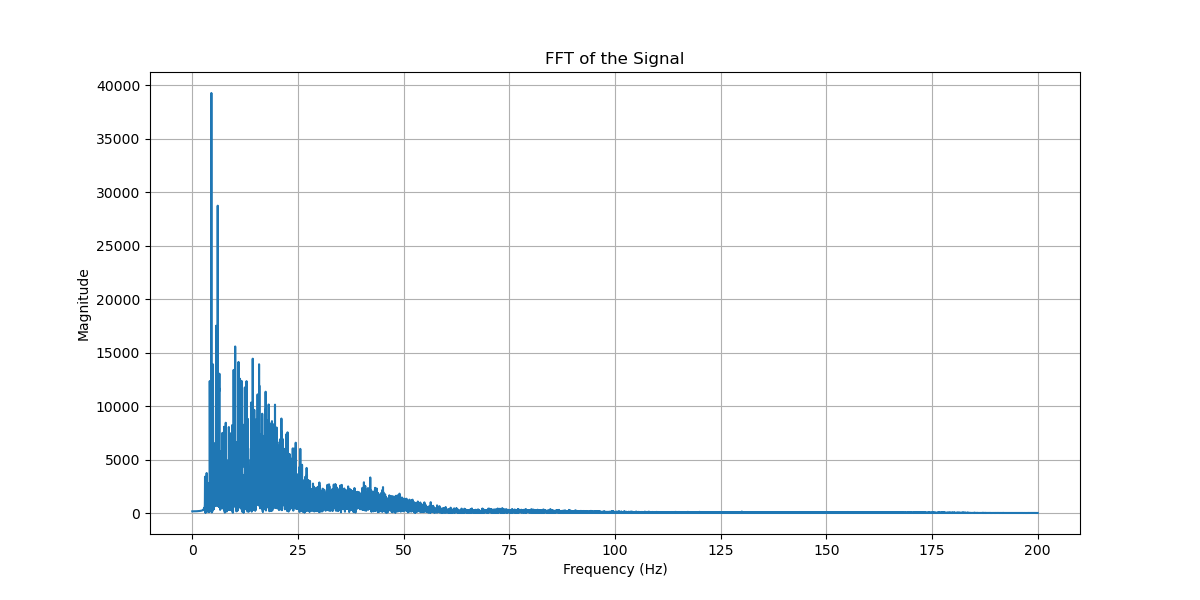

Frequency: 50.00 Hz, Magnitude: 762.06
Frequency: 100.00 Hz, Magnitude: 125.15
Frequency: 150.00 Hz, Magnitude: 75.97
Frequency: 199.98 Hz, Magnitude: 2.51


In [17]:
check_noise(s2.channel1, fs=sampling_rate)

In [18]:
def multi_channel_PLIC(signal, powerline_freq=50, fs=400, harmonics=3, plot_response=False):
    """
    Apply multiple notch filters to remove power-line interference and its harmonics.

    :param signal: Input ECG signal (numpy array)
    :param powerline_freq: Power-line frequency (Hz) (default: 50 Hz)
    :param fs: Sampling frequency (Hz) (default: 400 Hz)
    :param harmonics: Number of harmonics to remove (e.g., 3 removes 50, 100, 150 Hz)
    :param quality_factor: Quality factor of the notch filters (default: 30)
    :param plot_response: If True, plots the frequency response of the filter
    :return: Filtered signal
    """
    
    filtered_signal = signal.copy()

    # Plot frequency response setup
    if plot_response:
        plt.figure(figsize=(10, 5))
    
    for i in range(1, harmonics + 1):
        notch_freq = powerline_freq * i  # Compute harmonic frequency
        w0 = notch_freq / (fs / 2)  # Normalize frequency
        if i == 1:
            quality_factor = 20
        else:
            quality_factor = 30
        b, a = iirnotch(w0, quality_factor)

        # Apply notch filter
        filtered_signal = filtfilt(b, a, filtered_signal)

        # Plot frequency response
        if plot_response:
            w, h = freqz(b, a, fs=fs)
            plt.plot(w, 20 * np.log10(abs(h)), label=f'Notch at {notch_freq} Hz')

    if plot_response:
        plt.axvline(powerline_freq, color='r', linestyle='--', label='Fundamental')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Magnitude (dB)')
        plt.title('Notch Filter Frequency Response')
        plt.legend()
        plt.grid()
        plt.show()

    return filtered_signal

def Multi_Power_line_interference_canceller(fecg_df:pd.DataFrame)->pd.DataFrame:
    """
    This function takes a dataframe of FECG and apply a notch filter to remove the power-line interference.
    """
    dummy = fecg_df.copy()
    for i in dummy.columns:
        if(i != 'time'):
            dummy[i] = multi_channel_PLIC(dummy[i])
    return dummy

def visualize_results(corrupted_signal, cleaned_signal, time):
    """
    Visualizes the original ECG signal, corrupted signal, and cleaned signal.

    Parameters:
        ecg_signal (list): The original clean ECG signal.
        corrupted_signal (list): The corrupted signal (ECG + interference).
        cleaned_signal (list): The interference-free ECG signal.
        time (list): The time vector corresponding to the signal.
    """
    plt.figure(figsize=(12, 8))

    # Plot corrupted signal
    plt.subplot(2, 1, 1)
    plt.plot(time, corrupted_signal, label="Corrupted Signal", color='red')
    plt.title("Corrupted Signal (ECG + Interference)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.xticks(np.linspace(time.min(), time.max(), 10))  # Set 10 evenly spaced ticks


    # Plot cleaned ECG signal
    plt.subplot(2, 1, 2)
    plt.plot(time, cleaned_signal, label="Cleaned ECG Signal", color='green')
    plt.title("Cleaned ECG Signal")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.xticks(np.linspace(time.min(), time.max(), 10))  # Set 10 evenly spaced ticks


    plt.subplots_adjust(hspace=0.4)
    plt.show()


In [19]:
s3 = Multi_Power_line_interference_canceller(s2)

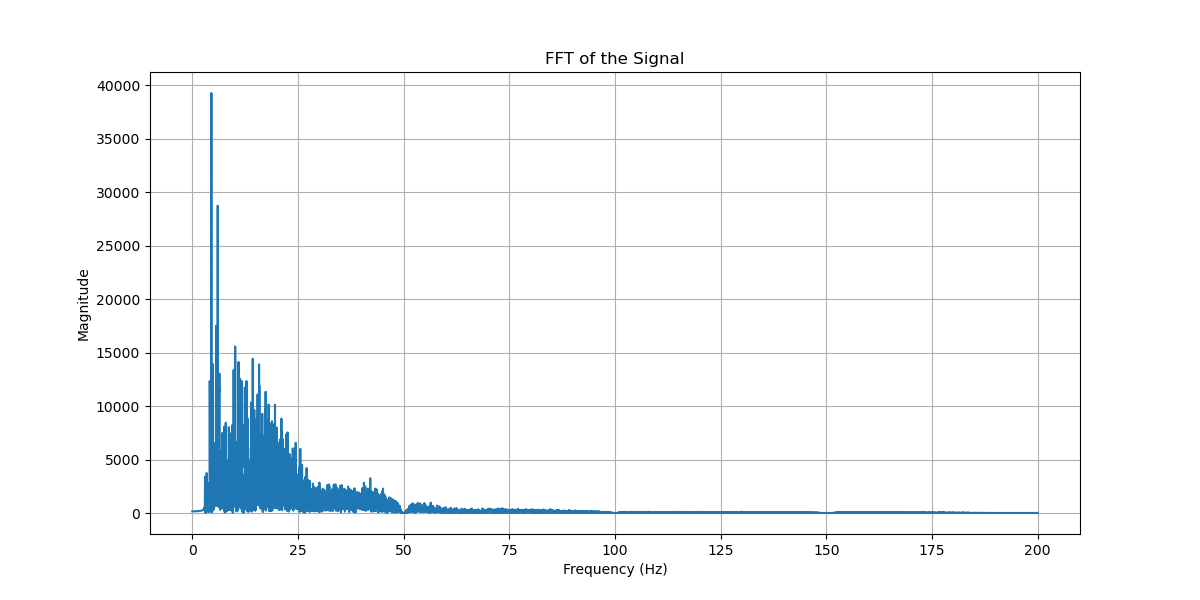

Frequency: 50.00 Hz, Magnitude: 3.20
Frequency: 100.00 Hz, Magnitude: 0.59
Frequency: 150.00 Hz, Magnitude: 0.22
Frequency: 199.98 Hz, Magnitude: 2.54


In [20]:
check_noise(s3.channel1)


In [557]:
def compute_sir(ecg_original, ecg_filtered, fs):
    """
    Computes the Signal-to-Interference Ratio (SIR) before and after filtering.

    :param ecg_original: Original ECG signal with power-line interference
    :param ecg_filtered: Filtered ECG signal
    :param fs: Sampling frequency (Hz)
    :return: SIR before filtering, SIR after filtering (both in dB)
    """

    # Power-line frequency (50 Hz or 60 Hz, depending on region)
    powerline_freq = 50  

    # Bandpass filter to isolate power-line interference
    nyquist = fs / 2
    band = [powerline_freq - 2, powerline_freq + 2]  # Small range around 50 Hz
    b, a = butter(4, [band[0] / nyquist, band[1] / nyquist], btype='bandpass')

    # Extract power-line noise component
    interference_before = filtfilt(b, a, ecg_original)
    interference_after = filtfilt(b, a, ecg_filtered)

    # Compute signal power (excluding interference)
    power_ecg = np.var(ecg_original) - np.var(interference_before)
    power_ecg_filtered = np.var(ecg_filtered) - np.var(interference_after)

    # Compute interference power
    power_noise_before = np.var(interference_before)
    power_noise_after = np.var(interference_after)

    # Compute SIR before and after filtering
    sir_before = 10 * np.log10(power_ecg / power_noise_before)
    sir_after = 10 * np.log10(power_ecg_filtered / power_noise_after)

    return sir_before, sir_after

# Example usage:
fs = 400  # Sampling rate (adjust to your actual data)
ecg_original = s2.channel4  # Example: Replace with real ECG data
ecg_filtered = s3.channel4  # Example: Replace with filtered ECG data

sir_before, sir_after = compute_sir(ecg_original, ecg_filtered, fs)
print(f"SIR Before Filtering: {sir_before:.2f} dB")
print(f"SIR After Filtering: {sir_after:.2f} dB")


SIR Before Filtering: 29.25 dB
SIR After Filtering: 36.67 dB


In [558]:
s3.head()

,time,channel1,channel2,channel3,channel4
0,0.0000,-0.148794,1.394433,0.071874,-0.039483
1,0.0025,-1.403440,0.487710,1.265299,-2.025218
2,0.0050,-1.667043,0.352442,1.221547,-2.093679
3,0.0075,-2.463596,-2.356652,1.340110,-2.351416
4,0.0100,-3.256596,-3.598533,1.169363,-1.327863


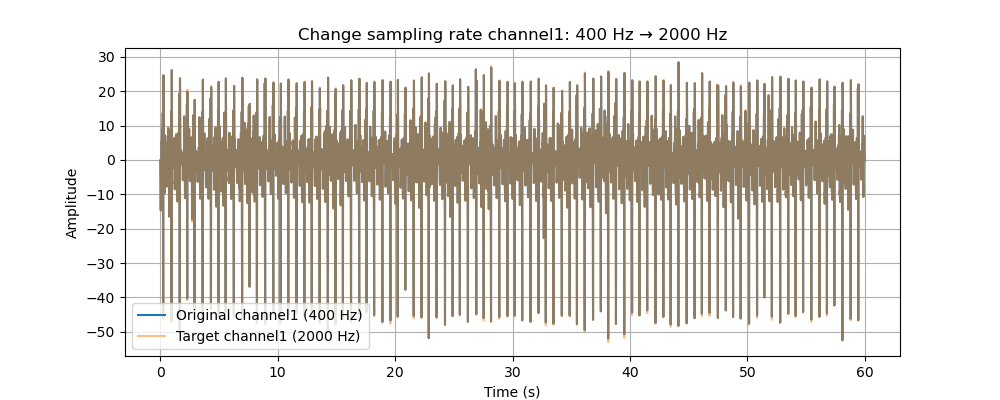

In [36]:
s4 = changeSamplingRate(s3, 400, 2000,plot_result=True)
sampling_rate = 2000  # Hz

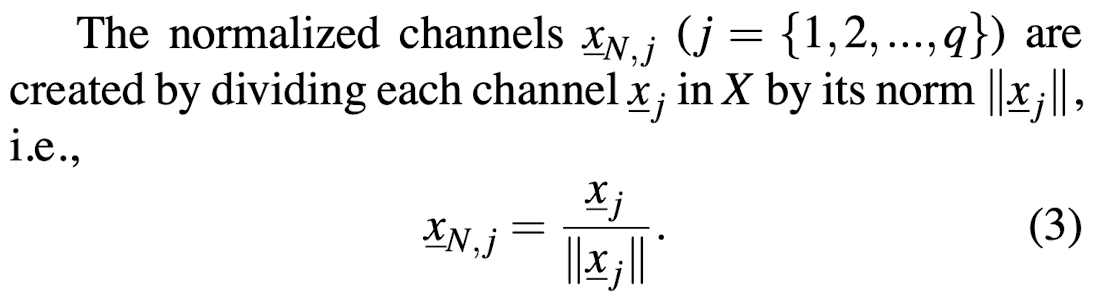

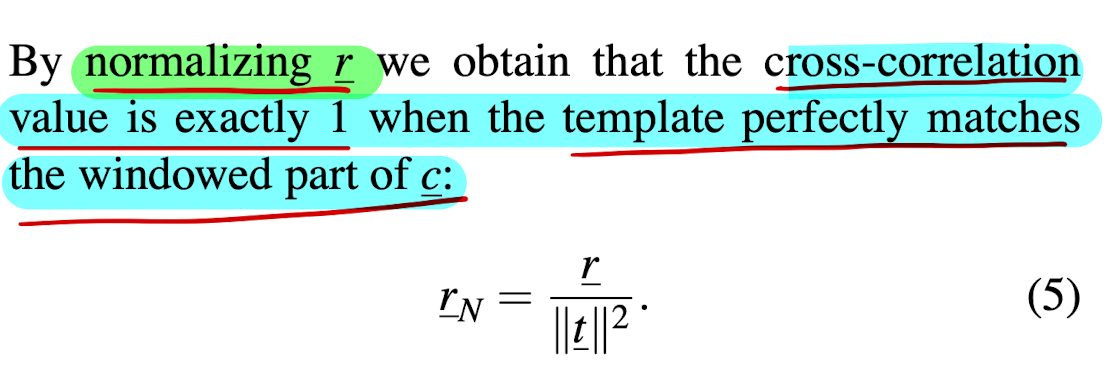

In [38]:
def multi_channel_QRS_enhancement(fecg_df:pd.DataFrame,show_plot=False)->pd.DataFrame:
    """
    This function takes a dataframe of FECG and enhances the QRS complex in the signal.
    """
    ecg_data = fecg_df.copy()  

    ecg_data.drop(columns=['time'], inplace=True)
    # print("Channel variance before normalization:")
    # print(ecg_data.var())
    # Step 1: Normalize the variance of each channel based on picture above
    normalized_data = ecg_data / np.linalg.norm(ecg_data, axis=0)
    # print("Channel variance after normalization:")
    # print(normalized_data.var())
    # Step 2: Perform PCA on the normalized data
    pca = PCA(n_components=1)  # Extract only the first principal component
    principal_component = pca.fit_transform(normalized_data)

    # Step 3: Plot the first principal component
    if show_plot:
        plt.figure(figsize=(12, 6))
        # plt.plot(ecg_data, label="ECG Data (3 Channels)", alpha=0.2)
        plt.plot(principal_component, label="First Principal Component (PC1)")
        plt.title("First Principal Component of Multi-Channel ECG Data")
        plt.xlabel("Samples")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.show()
    return principal_component
    
def find_window_maxima(signal)-> np.array:
    """
    Finds the sample with the maximum absolute amplitude in each 1-second window.

    Args:
        signal (np.array): Input signal.
        fs (int): Sampling frequency in Hz.

    Returns:
        List of indices of the maximum samples in each window.
    """
    window_size = 2000  # 1 second window at 2000 Hz
    maxima_indices = []

    for i in range(0, len(signal), window_size):
        window = signal[i:i + window_size]
        max_idx = np.argmax(np.abs(window)) + i  # Find index of max absolute amplitude
        maxima_indices.append(max_idx)

    return np.array(maxima_indices)

def extract_qrs_templates(signal, maxima_indices, fs)-> tuple :
    """
    Extracts QRS templates from the signal based on maxima indices.

    Args:
        signal (np.array): Input signal.
        maxima_indices (list): Indices of maxima in each window.
        fs (int): Sampling frequency in Hz.

    Returns:
        List of QRS templates (np.array) and their corresponding indices.
    """
    template_duration = 0.1  # Duration of the template in seconds
    template_samples = int(template_duration * fs)  # Number of samples in the template
    half_template = template_samples // 2

    templates = []
    template_indices = []

    for idx in maxima_indices:
        start = max(0, idx - half_template)  # Ensure index does not go negative
        end = min(len(signal), idx + half_template)  # Ensure index does not exceed signal length
        
        template = signal[start:end]

        if len(template) == template_samples:
            templates.append(template)
            template_indices.append(idx)
        else :
            # If the template is shorter than expected, we can skip it
            print(f"Template at index {idx} is shorter than expected. Skipping.")
            # template = np.pad(template, (0, template_samples - len(template)), 'constant')
            # templates.append(template)
            # template_indices.append(idx)
            continue
  
    return np.array(templates), np.array(template_indices)

def compute_cross_correlation(signal, templates):
    """
    Computes the cross-correlation between the QRS templates and the signal.

    Args:
        signal (np.array): Input signal.
        templates (list of np.array): List of QRS templates.

    Returns:
        np.array: Averaged cross-correlation vector.
    """
    # cross_correlations = []
    avg_template = np.mean(templates, axis=0)
    r = correlate(signal, avg_template, mode="same")
    template_energy = np.linalg.norm(avg_template) ** 2
    cross_correlation = r / template_energy
    # for template in templates:

    #     # Compute cross-correlation
    #     r = correlate(signal, template, mode="same")
    #     # Normalize cross-correlation
    #     template_energy = np.linalg.norm(template)**2 
    #     if template_energy > 0:
    #         r_normalized = r / template_energy
    #     else:
    #         r_normalized = r  

    #     cross_correlations.append(r_normalized)

    # Compute the average cross-correlation over all templates
    # avg_cross_correlation = np.mean(cross_correlations, axis=0)

    return cross_correlation

def threshold_cross_correlation(cross_correlation, threshold):
    """
    Applies thresholding to identify QRS candidates from cross-correlation results.

    Args:
        cross_correlation (np.array): Cross-correlation vector.
        threshold (float): Threshold value for QRS detection.

    Returns:
        np.array: Indices where QRS candidates are detected.
    """
    # Find indices where correlation exceeds the threshold
    qrs_candidates = np.where(cross_correlation > threshold)[0]
    return qrs_candidates

def refine_qrs_candidates(qrs_candidates, cross_correlation, fs, min_distance):
    """
    Refines QRS candidates using heuristic rules.

    Args:
        qrs_candidates (np.array): QRS candidate indices.
        cross_correlation (np.array): Cross-correlation vector.
        fs (int): Sampling frequency in Hz.
        min_distance (float): Minimum distance between QRS peaks (in seconds).

    Returns:
        np.array: Refined QRS peak positions.
    """
    refined_positions = []
    prev_index = -np.inf  # Track last valid QRS peak

    for idx in qrs_candidates:
        if idx - prev_index > min_distance * fs:
            refined_positions.append(idx)
            prev_index = idx
        else:
            # Retain the candidate with the highest correlation
            if cross_correlation[idx] > cross_correlation[prev_index]:
                refined_positions[-1] = idx
                prev_index = idx

    return np.array(refined_positions)

In [ ]:
s4

In [586]:
snrs = compute_channel_snrs(s4)
snrs

{'channel1': np.float64(9.73448564442528),
 'channel2': np.float64(10.686234364607618),
 'channel3': np.float64(11.706368000309837),
 'channel4': np.float64(11.075164324479827)}

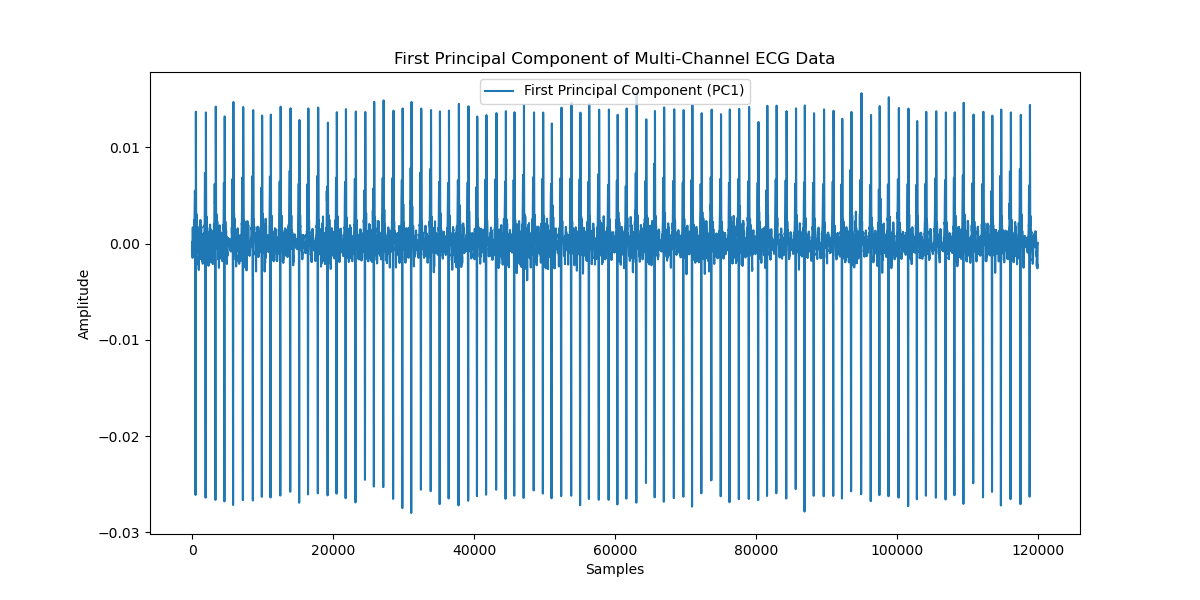

In [39]:
s4_pca = multi_channel_QRS_enhancement(s4,show_plot=True)

In [565]:
snr_ =estimate_snr(s4_pca)
snr_

np.float64(12.516229777324208)

In [40]:
def QRS_detector(pca: pd.DataFrame, sampling_rate=2000,threshold = 0.5, min_distance = 0.5, show_plot=False):
    """
    Detects the QRS complexes from a multi-channel FECG signal.

    Args:
        pca (pd.DataFrame): Multi-channel ECG dataframe (assumes 'time' column is present).
        sampling_rate (int): Sampling frequency (Hz). Default is 400 Hz.
        show_plot (bool): If True, plots QRS detection.
        threshold (float): Threshold for QRS detection.
        min_distance (float): Minimum distance between QRS peaks (in seconds).

    Returns:
        np.array: Detected QRS peak indices.
    """

    # Step 2: Find Maxima in 1-Second Windows**
    maxima_indices = find_window_maxima(pca)

    # Step 3: Extract QRS Templates**
    templates,_ = extract_qrs_templates(pca, maxima_indices, sampling_rate)

    # Step 4: Compute Cross-Correlation**
    cross_correlations = compute_cross_correlation(pca, templates)  # Single array now
 
    # Step 5: Apply Thresholding**
    qrs_candidates = threshold_cross_correlation(cross_correlations, threshold)

    # Step 6: Refine QRS Candidates**
    refined_qrs_positions = refine_qrs_candidates(qrs_candidates, cross_correlations, sampling_rate, min_distance)

    if show_plot:
        time_axis = np.arange(len(pca)) / sampling_rate  # Convert samples to time
        plt.figure(figsize=(12, 5))
        plt.plot(time_axis, pca, label="Enhanced QRS Signal", alpha=0.8)
        plt.scatter(refined_qrs_positions / sampling_rate, pca[refined_qrs_positions],
                    color='red', marker='o', label="Detected QRS Peaks")
        
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.title("QRS Detection")
        plt.legend()
        plt.grid()
        plt.show()

    return refined_qrs_positions

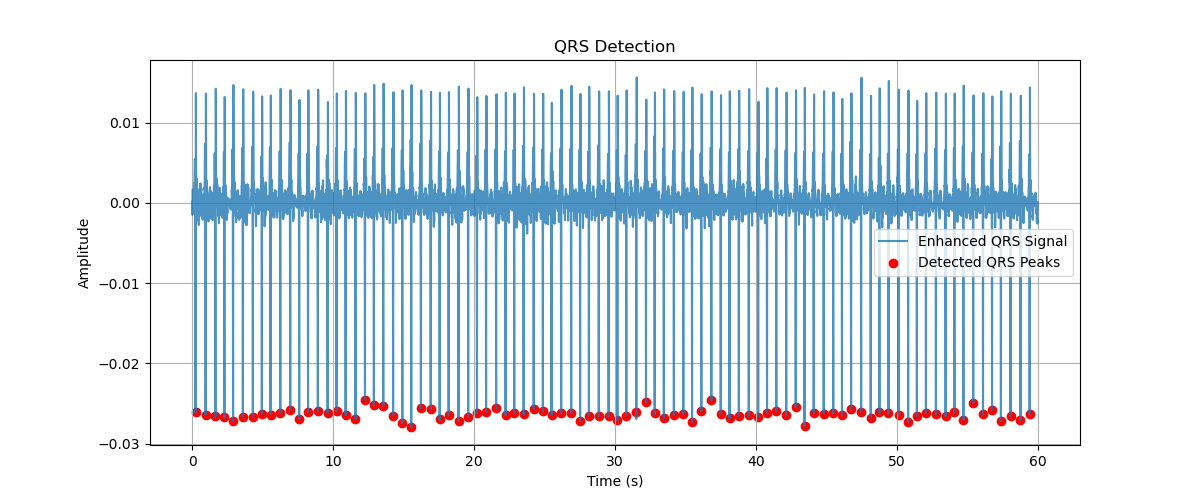

In [41]:
qrs_peaks = QRS_detector(s4_pca,sampling_rate=2000, show_plot=True)

In [594]:
print(len(qrs_peaks))

90


In [42]:
def refine_peaks_per_channel(ecg_df, pca_peaks, fs, window_ms=70):
    """
    Refine the QRS peak positions per channel based on local max/min in a short window.

    Args:
        ecg_df (pd.DataFrame): Original ECG data with multiple channels + 'time'.
        pca_peaks (np.array): QRS peak positions detected from PC1.
        fs (int): Sampling frequency (e.g., 2000).
        window_ms (int): Half-window size around each peak in milliseconds.

    Returns:
        dict: Dictionary with channel name as key and list of refined QRS peak indices as value.
    """
    half_window = int((window_ms / 1000) * fs)
    refined_peaks = {}

    for col in ecg_df.columns:
        if col == 'time':
            continue
        signal = ecg_df[col].values
        channel_peaks = []

        for peak in pca_peaks:
            start = max(0, peak - half_window)
            end = min(len(signal), peak + half_window)

            window = signal[start:end]
            if np.abs(window.max()) > np.abs(window.min()):
                local_peak = np.argmax(window)
            else:
                local_peak = np.argmin(window)

            aligned_index = start + local_peak
            channel_peaks.append(aligned_index)

        refined_peaks[col] = channel_peaks

    return refined_peaks

refined_peaks_by_channel = refine_peaks_per_channel(s4, qrs_peaks, fs=2000)


In [507]:
len(refined_peaks_by_channel['channel1'])

90

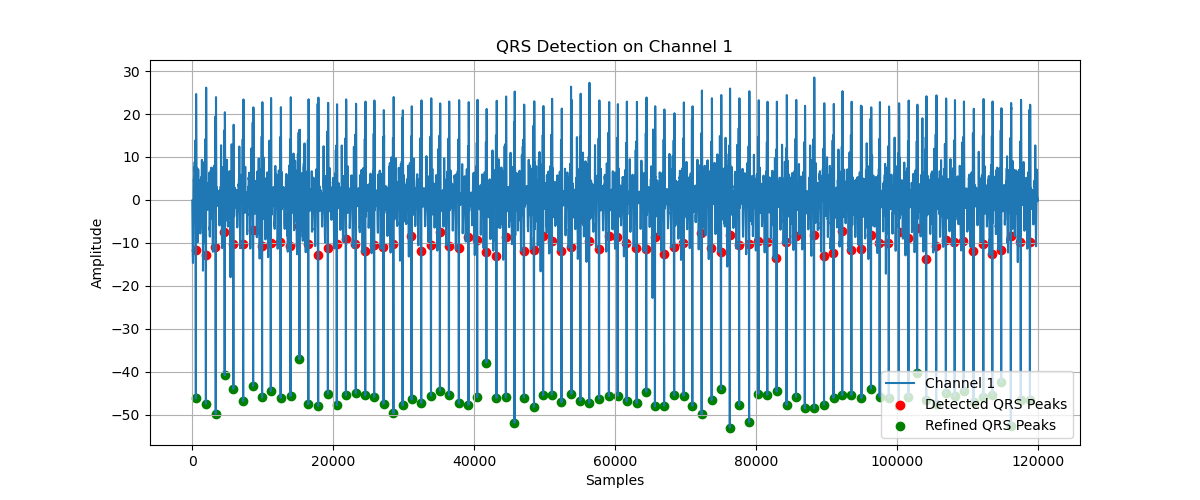

In [595]:
#plot the detected QRS peaks 
plt.figure(figsize=(12, 5))
plt.plot(s4.channel1, label="Channel 1")
plt.scatter(qrs_peaks, s4.channel1[qrs_peaks], color='red', marker='o', label="Detected QRS Peaks")
plt.scatter(refined_peaks_by_channel['channel1'], s4.channel1[refined_peaks_by_channel['channel1']], color='green', marker='o', label="Refined QRS Peaks")

plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title("QRS Detection on Channel 1")
plt.legend()
plt.grid()
plt.show()

In [47]:
# MECG cancellation: prepare windows and implement subtraction loop

def extract_mecg_windows(signal, qrs_peaks, fs, pre_qrs=0.25, post_qrs=0.45):
    """
    Extracts MECG windows around each QRS peak.

    Args:
        signal (np.array): Enhanced ECG signal.
        qrs_peaks (np.array): Detected QRS indices.
        fs (int): Sampling frequency in Hz.
        pre_qrs (float): Seconds before the QRS to start the window.
        post_qrs (float): Seconds after the QRS to end the window.

    Returns:
        List of MECG window arrays and their original indices.
    """
    window_size = int((pre_qrs + post_qrs) * fs)
    half_pre = int(pre_qrs * fs)
    windows = []
    indices = []

    for peak in qrs_peaks:
        start = peak - half_pre
        if start < 0:
            start = 0
        end = start + window_size
        if end > len(signal):
            end = len(signal)
        windows.append(signal[start:end])
        indices.append((start, end))

    return windows, indices

def compute_least_min_square(mu_P, mu_QRS, mu_T, m,print_scaling=False,index=None):
    """
    Constructs M using zero-padded block columns for mu_P, mu_QRS, and mu_T,
    Solves the least-squares problem to estimate m_hat (estimated MECG).
    """
    # # normalize them for problem at index 20
    # mu_P  /= np.linalg.norm(mu_P)
    # mu_QRS  /= np.linalg.norm(mu_QRS)
    # mu_T  /= np.linalg.norm(mu_T)
    # m  /= np.linalg.norm(m)


    # Determine the lengths
    len_P = len(mu_P)
    len_QRS = len(mu_QRS)
    len_T = len(mu_T)

    # Pad mu_P: on bottom
    col_P = np.concatenate([mu_P, np.zeros(len_QRS + len_T)])

    # Pad mu_QRS: top and bottom
    col_QRS = np.concatenate([np.zeros(len_P), mu_QRS, np.zeros(len_T)])

    # Pad mu_T: on top
    col_T = np.concatenate([np.zeros(len_P + len_QRS), mu_T])

    # Stack to form M matrix: shape (total_len, 3)
    M = np.column_stack([col_P, col_QRS, col_T])

    # Solve least-squares: a = (MᵀM)⁻¹ Mᵀ m
    MTM = M.T @ M
    MTm = M.T @ m
    a = np.linalg.pinv(MTM) @ MTm
    m_hat = M @ a
    if print_scaling:
        print(f"scaling factor for index {index} : {a}")
        plt.figure(figsize=(12, 6))
        plt.plot(m, label="m full")
        plt.title("m_full") 
        plt.xlabel("Samples")   
        plt.ylabel("Amplitude")
        plt.legend()    
        plt.grid()
        plt.show()

    return m_hat 

def mecg_cancellation(ecg_df,refined_qrs_peaks, fs, N=10):
    """
    Applies MECG cancellation using scaling of P, QRS, T wave and subtracts only where m̂ is defined.

    Args:
        ecg_df (pd.DataFrame): Dataframe containing the ECG signal.
        refined_qrs_peaks (dict): QRS peak positions detected from PC1, refined for each channel.
        fs (int): Sampling frequency in Hz.
        N (int): Number of windows to average for scaling.

    Returns:
        pd.DataFrame: Dataframe with cleaned ECG signal.
    """
    cleaned_signal = ecg_df.copy()
    windows_per_channel = {}
    skipped_windows_per_channel = {}
    # Extract MECG windows
    for column in cleaned_signal.columns:
        if column == 'time':
            continue
        signal = cleaned_signal[column].values
        channel_qrs_peaks = refined_qrs_peaks[column]
        windows, window_indices = extract_mecg_windows(signal,channel_qrs_peaks,fs)
        windows_per_channel[column] = windows
        # mu_test = np.mean(windows[10:20], axis=0)
        # plt.figure(figsize=(12, 6))
        # for i in range(10, 20):
        #     plt.plot(windows_per_channel[column][i], label=f"Window {i+1}", alpha=0.2)
        # plt.plot(mu_test, label="Mean Window", color='red', linewidth=2)
        # plt.title(f"window extraction for {column}") 
        # plt.xlabel("Samples")
        # plt.ylabel("Amplitude") 
        # plt.legend()
        # plt.grid()
        # plt.show()
    
        for i in range(N, len(windows)):
            m = windows[i]
            mu = np.mean(windows[i - N:i], axis=0)

            # Extract P, QRS, T segments
            # fs = 2000 Hz
            # P: 0.25s before QRS
            # QRS: 0.05s before and after R 
            # T: 0.45s after QRS
            qrs_center = int(0.25 * fs)
            # qrs_center = np.argmax(m)  # Find the QRS center in the current window


            # QRS = R ± 0.05s
            qrs_start = qrs_center - int(0.05 * fs)
            qrs_end   = qrs_center + int(0.05 * fs)

            # P wave: 0.20s before QRS window
            p_start = qrs_start - int(0.20 * fs)
            p_end   = qrs_start

            # T wave: 0.40s after QRS window
            t_start = qrs_end
            t_end   = qrs_end + int(0.40 * fs)

            # From averaged window (μ)
            mu_P   = mu[p_start:p_end]
            mu_QRS = mu[qrs_start:qrs_end]
            mu_T   = mu[t_start:t_end]

            # From current window (m)
            m_P   = m[p_start:p_end]
            m_QRS = m[qrs_start:qrs_end]
            m_T   = m[t_start:t_end]

            m_full = np.concatenate([m_P, m_QRS, m_T])
            
            # Use least-min-square estimator
            m_hat = compute_least_min_square(mu_P, mu_QRS, mu_T, m_full)

            # plot the original and estimated signals
            # if i ==43:
            #     plt.figure(figsize=(12, 6))
            #     plt.plot(m_full, label="Original Window", alpha=0.5)
            #     plt.plot(m_hat, label="Estimated Window", color='red', linewidth=2)
            #     plt.title(f"Window index {i} for {column}") 
            #     plt.xlabel("Samples")
            #     plt.ylabel("Amplitude") 
            #     plt.legend()
            #     plt.grid()
            #     plt.show()


            start, end = window_indices[i]
            # Subtract m_hat from the original signal if it is a good estimate
            # Check if the estimated signal is close to the original
            corr = np.corrcoef(m_full, m_hat)[0, 1]
            if corr > 0.70:
                signal[start:end] -= m_hat
            else:
                # If the correlation is low, skip this window
                if column not in skipped_windows_per_channel:
                    skipped_windows_per_channel[column] = []
                skipped_windows_per_channel[column].append(window_indices[i])
                print(f"Skipped window {i} for {column} due to low correlation: {corr:.2f}")
                continue
        
        # Remove the first 10 peaks
        for i in range(N):
            m = windows[i] 
            mu = np.mean(windows[0:10], axis=0)
            qrs_center = int(0.25 * fs)
            
            # QRS = R ± 0.05s
            qrs_start = qrs_center - int(0.05 * fs)
            qrs_end   = qrs_center + int(0.05 * fs)

            # P wave: 0.20s before QRS window
            p_start = qrs_start - int(0.20 * fs)
            p_end   = qrs_start

            # T wave: 0.40s after QRS window
            t_start = qrs_end
            t_end   = qrs_end + int(0.40 * fs)

            # From averaged window (μ)
            mu_P   = mu[p_start:p_end]
            mu_QRS = mu[qrs_start:qrs_end]
            mu_T   = mu[t_start:t_end]

            # From current window (m)
            m_P   = m[p_start:p_end]
            m_QRS = m[qrs_start:qrs_end]
            m_T   = m[t_start:t_end]

            m_full = np.concatenate([m_P, m_QRS, m_T])

            # Use least-min-square estimator
            m_hat = compute_least_min_square(mu_P, mu_QRS, mu_T, m_full)

            # Subtract m_hat from the original signal
            start, end = window_indices[i]
            signal[start:end] -= m_hat
            

        # Update the cleaned signal in the dataframe
        cleaned_signal[column] = signal
        # Update the cleaned signal in the dataframe
        cleaned_signal[column] = signal


    return cleaned_signal,skipped_windows_per_channel



In [48]:
s5,skipped_windows_per_channel = mecg_cancellation(s4,refined_peaks_by_channel,sampling_rate,N=10)

Skipped window 20 for channel1 due to low correlation: 0.35
Skipped window 33 for channel1 due to low correlation: 0.67
Skipped window 20 for channel2 due to low correlation: 0.36
Skipped window 10 for channel3 due to low correlation: 0.50
Skipped window 21 for channel3 due to low correlation: 0.54
Skipped window 36 for channel3 due to low correlation: 0.66
Skipped window 42 for channel3 due to low correlation: 0.51
Skipped window 48 for channel3 due to low correlation: 0.70
Skipped window 49 for channel3 due to low correlation: 0.54
Skipped window 60 for channel3 due to low correlation: 0.68
Skipped window 71 for channel3 due to low correlation: 0.63
Skipped window 72 for channel3 due to low correlation: 0.16
Skipped window 73 for channel3 due to low correlation: 0.55
Skipped window 74 for channel3 due to low correlation: 0.28
Skipped window 75 for channel3 due to low correlation: 0.42
Skipped window 76 for channel3 due to low correlation: 0.67
Skipped window 20 for channel4 due to lo

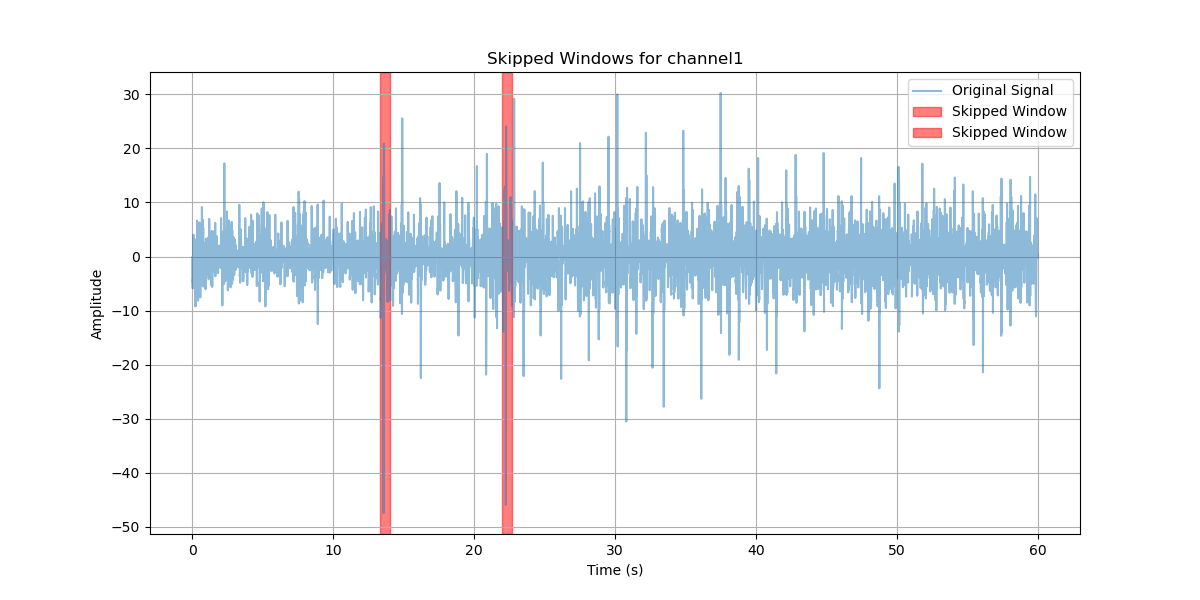

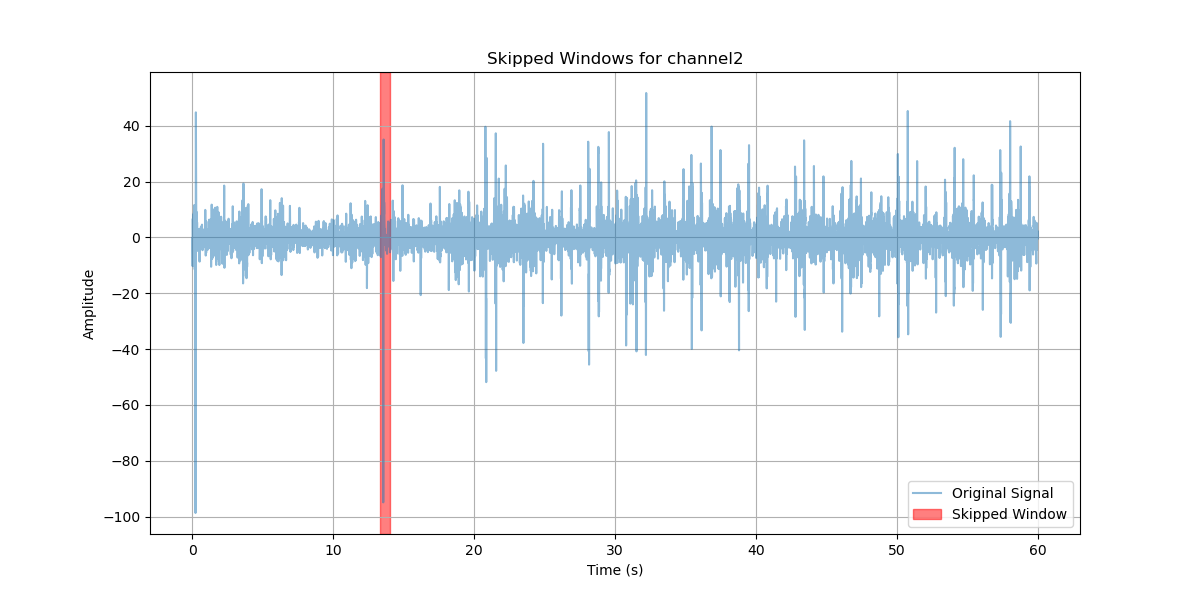

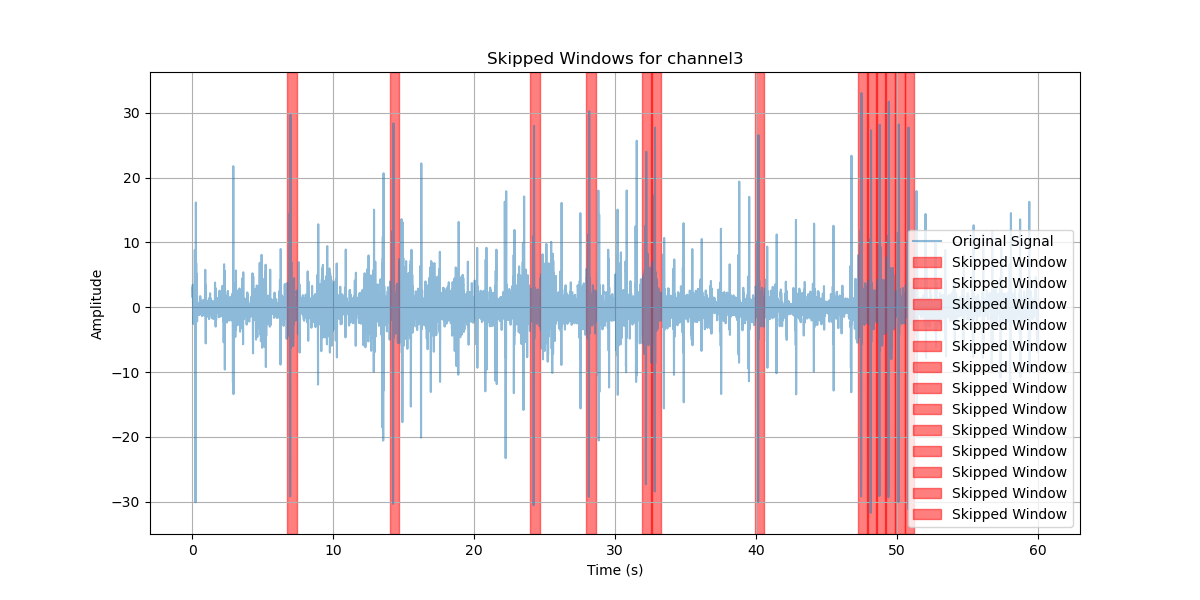

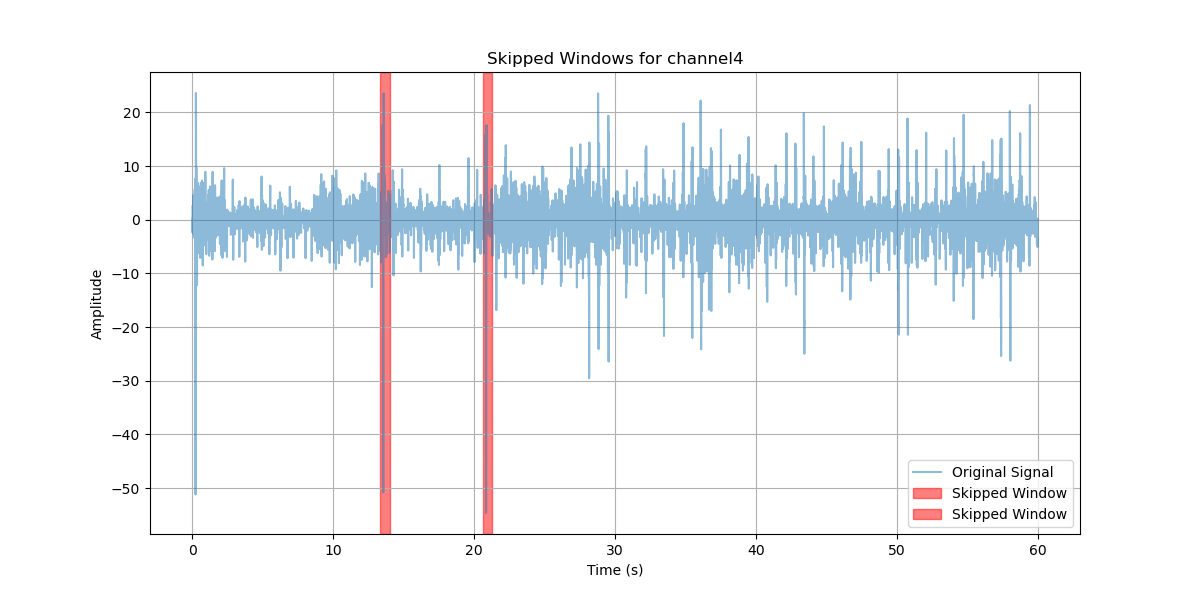

In [51]:
def plot_skipped_windows(skipped_windows_per_channel, fs, signal):
    """
    Plots the skipped windows for each channel.

    Args:
        skipped_windows_per_channel (dict): Dictionary of skipped windows for each channel.
        fs (int): Sampling frequency in Hz.
        signal (np.array): Original signal to plot.
    """
    time = np.arange(len(signal)) / fs

    for channel, windows in skipped_windows_per_channel.items():
        plt.figure(figsize=(12, 6))
        plt.plot(time, signal[channel], label="Original Signal", alpha=0.5)
        for start, end in windows:
            plt.axvspan(start / fs, end / fs, color='red', alpha=0.5, label="Skipped Window")
            signal.loc[start:end,channel] = 0
        plt.title(f"Skipped Windows for {channel}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid()
        plt.show()
# Plot skipped windows for each channel
plot_skipped_windows(skipped_windows_per_channel, sampling_rate, s5)

In [55]:
def plot_mecg_removal_example(enhanced_signal,cleaned_signal, qrs_peaks, fs, i=10):
    """
    Visualizes one example of MECG cancellation by comparing the original and cleaned signals
    in a window around a selected QRS peak.
    
    Args:
        enhanced_signal (np.ndarray): Original signal before subtraction
        cleaned_signal (np.ndarray): Signal after MECG subtraction
        qrs_peaks (np.ndarray): Detected QRS peaks
        fs (int): Sampling frequency
        i (int): Index of QRS peak to visualize
    """
    pre_qrs = int(0.25 * fs)
    post_qrs = int(0.45 * fs)
    center = qrs_peaks[i]
    start = center - pre_qrs
    end = center + post_qrs

    t = np.arange(start, end) / fs
    plt.figure(figsize=(12, 4))
    plt.plot(t, enhanced_signal[start:end], label="Before Cancellation (Enhanced)", alpha=0.6)
    plt.plot(t, cleaned_signal[start:end], label="After Cancellation (Cleaned)")
    plt.axvline(center / fs, color='r', linestyle='--', label='QRS Center')
    plt.title(f"MECG Cancellation Example (QRS index: {i})")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

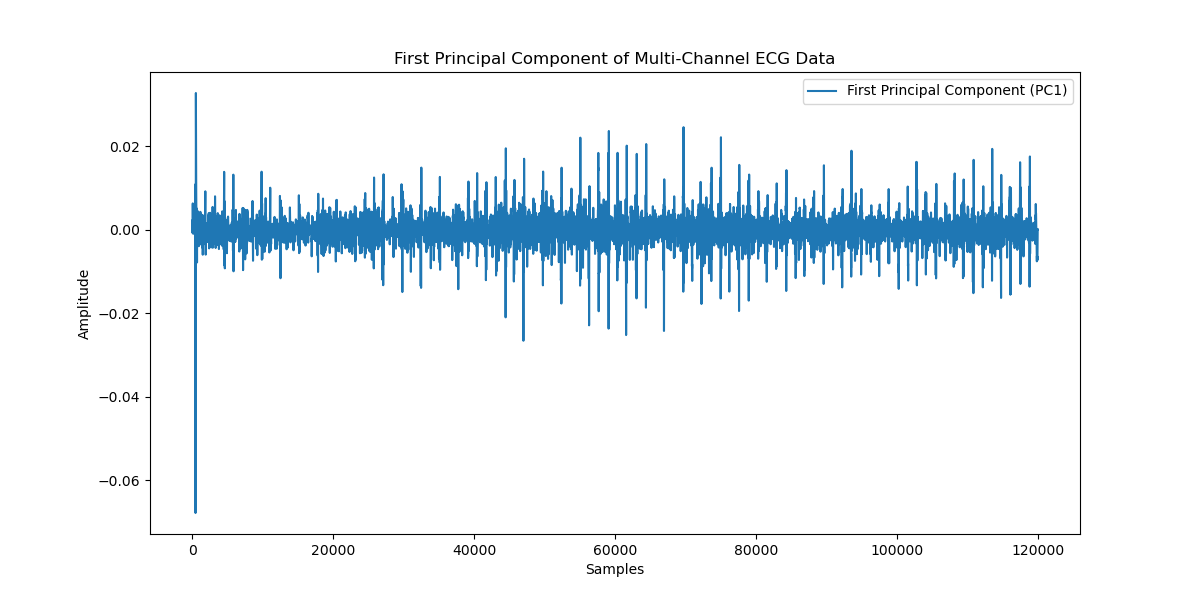

In [52]:
s5_pca = multi_channel_QRS_enhancement(s5,show_plot=True)


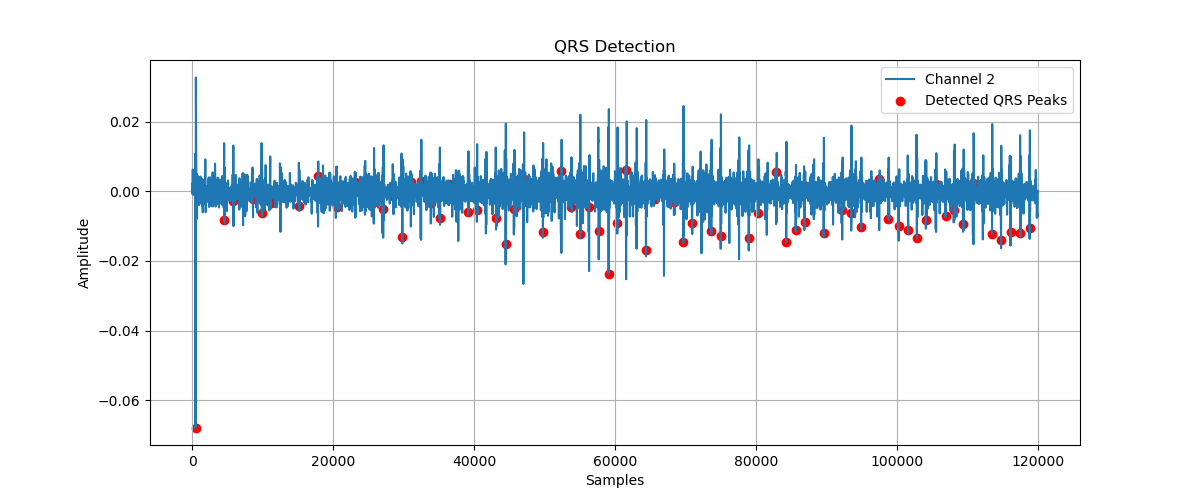

In [53]:
#plot the detected QRS peaks 
plt.figure(figsize=(12, 5))
plt.plot(s5_pca, label="Channel 2")
plt.scatter(qrs_peaks, s5_pca[qrs_peaks], color='red', marker='o', label="Detected QRS Peaks")

plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title("QRS Detection")
plt.legend()
plt.grid()
plt.show()

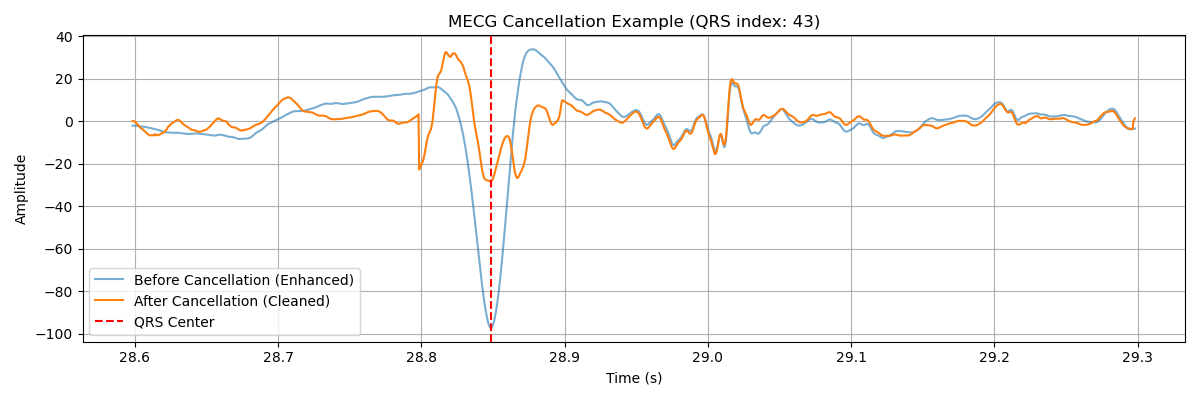

In [56]:
plot_mecg_removal_example(s4.channel2,s5.channel2,refined_peaks_by_channel['channel2'],sampling_rate,i=43)

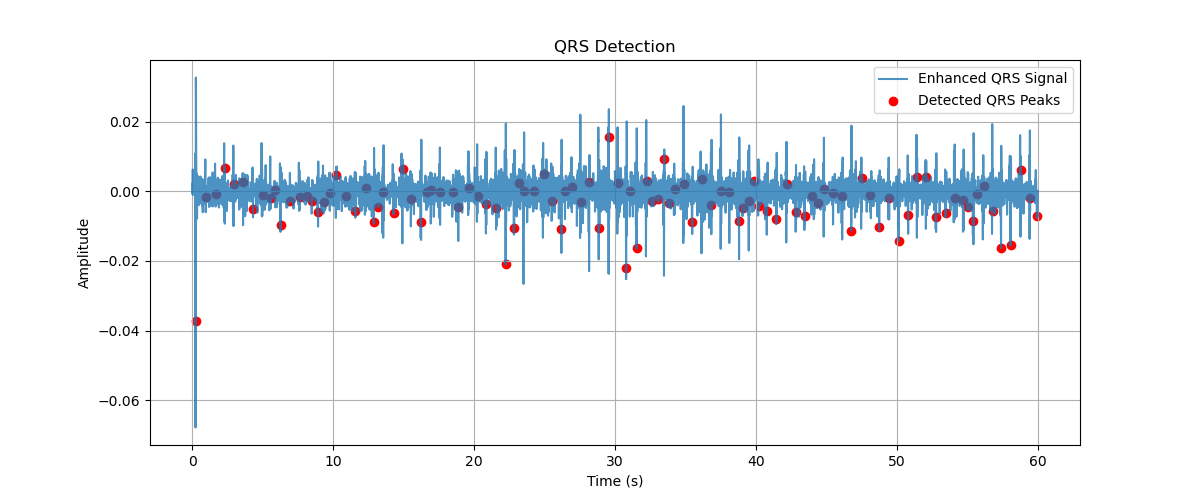

In [71]:
qrs_peaks_fetal = QRS_detector(s5_pca,sampling_rate=2000, show_plot=True,threshold=0.5, min_distance=0.3)

In [70]:
len(qrs_peaks_fetal)


101

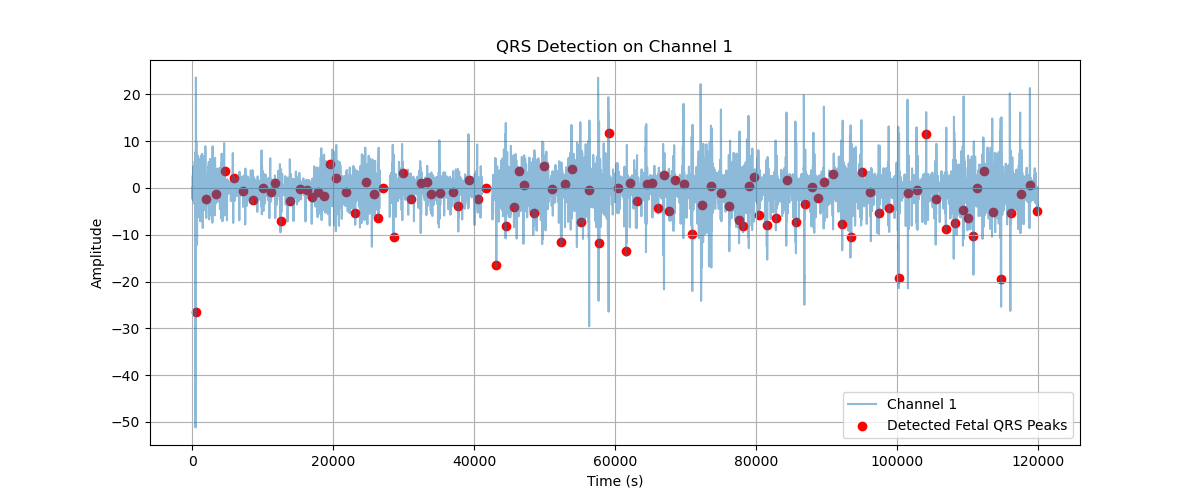

In [84]:
#plot the detected QRS peaks 
plt.figure(figsize=(12, 5))
plt.plot(s5.channel4, label="Channel 1", alpha=0.5)
plt.scatter(qrs_peaks_fetal, s5.channel4[qrs_peaks_fetal], color='red', marker='o', label="Detected Fetal QRS Peaks")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("QRS Detection on Channel 1")
plt.legend()
plt.grid()
plt.show()

In [ ]:
def average_fecg_complex(cleaned_ecg_df, fetal_qrs_peaks, fs, window_sec=0.):
    """
    Computes the average FECG complex for each channel over fetal QRS peaks.
    
    Args:
        cleaned_ecg_df (pd.DataFrame): MECG-cancelled multi-channel ECG.
        fetal_qrs_peaks (np.array): Detected fetal QRS indices.
        fs (int): Sampling frequency in Hz.
        window_sec (float): Total window length in seconds (e.g., 0.6s).
    
    Returns:
        dict: {channel_name: avg_fecg_segment (np.array)}
    """
    window_len = int(window_sec * fs)
    half_len = window_len // 2

    avg_complexes = pd.DataFrame()
    # Initialize a dictionary to store average complexes for each channel
    

    for col in cleaned_ecg_df.columns:
        if col == "time":
            continue

        segments = []
        signal = cleaned_ecg_df[col].values

        for peak in fetal_qrs_peaks:
            start = peak - half_len
            end = peak + half_len

            if start >= 0 and end < len(signal):
                segments.append(signal[start:end])

        if segments:
            avg_complex = np.mean(segments, axis=0)
            avg_complexes[col] = avg_complex

    return avg_complexes


In [74]:
average_fecg_complexes = average_fecg_complex(s5, qrs_peaks_fetal, fs=2000, window_sec=0.6)

In [219]:
average_fecg_complexes.head()


,channel1,channel2,channel3,channel4
0,0.524057,-2.593767,-0.924720,-1.120009
1,0.544885,-2.569406,-0.949520,-1.152182
2,0.562064,-2.548499,-0.975078,-1.187577
3,0.575304,-2.532217,-1.001026,-1.227103
4,0.584772,-2.520979,-1.027078,-1.271458


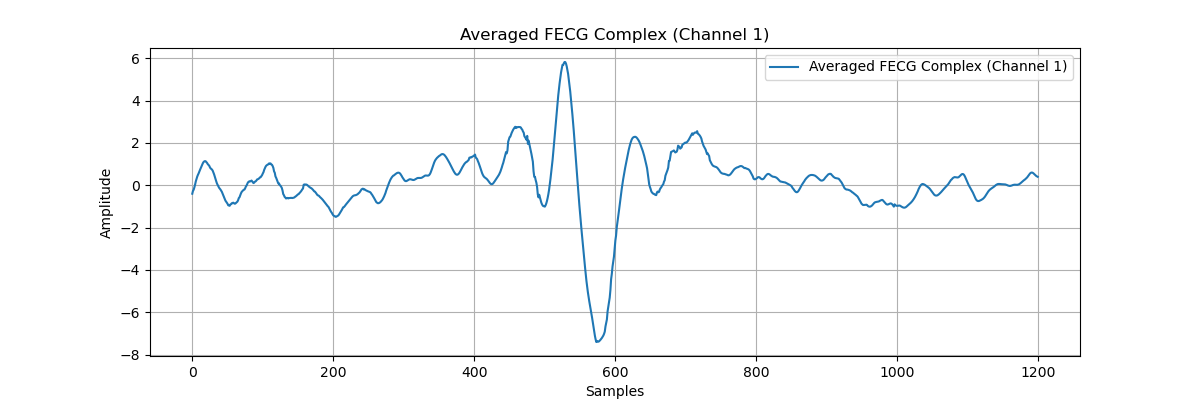

In [82]:
plt.figure(figsize=(12, 4))
plt.plot(average_fecg_complexes.channel2, label="Averaged FECG Complex (Channel 1)")
plt.title("Averaged FECG Complex (Channel 1)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()


In [76]:
def compute_final_avg_fecg(avg_complexes):
    return np.mean(avg_complexes, axis=1).values


In [77]:
final_avg_fecg = compute_final_avg_fecg(average_fecg_complexes)

In [223]:
final_avg_fecg.shape

(1200,)

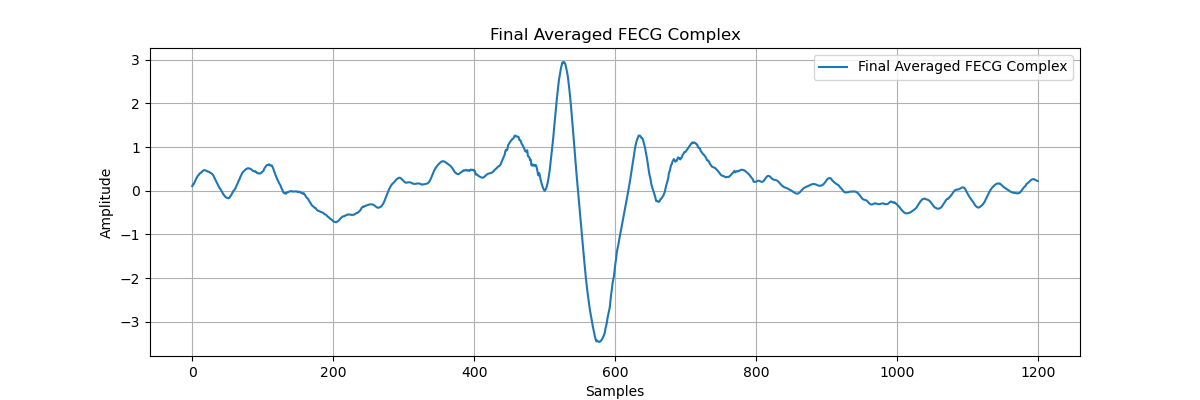

In [78]:
plt.figure(figsize=(12, 4))
plt.plot(final_avg_fecg, label="Final Averaged FECG Complex")
plt.title("Final Averaged FECG Complex")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()